# Classifier eval: Luna vs Sol vs Jev

Answers the question from `docs/DECISIONS.md` D-29 (Sol) and D-43/D-44 (Jev): does `gpt-6-sol`
(~20x `gpt-6-luna`'s price) or TypeSafe's Jev, served through Vercel's AI Gateway (cheaper than
Luna), earn a change of default on the classifier call, the highest-volume LLM call in the
pipeline (one per `(article, topic)` candidate)? All three classifiers implement the same
`Classifier` protocol, so this notebook calls the production adapter classes directly for each one.

Jev only runs if `AI_GATEWAY_API_KEY` is set (`get_settings().ai_gateway_api_key`); otherwise it's
skipped with a printed note and the notebook falls back to Luna vs Sol only. Luna is also scored a
**second time** (`luna_rerun`, same instance, separate cache) purely to measure Luna's own
run-to-run noise -- the yardstick D-44's Jev non-inferiority rule is judged against.

Jev is scored with the **v2** questions (`JEV_PROMPT_VERSION = "jev.v2"`, D-45): graded `score`
questions for relevance to the one topic being scored and for newsworthiness, like Luna/Sol get,
instead of v1's topic-vs-"none" `choice` and a `boolean`, which saturated at 0/1. v1's cached
scores are kept frozen as `jev_v1` (`results/scores_jev_v1.jsonl`) and shown for comparison only;
it is not a decision candidate.

**Before running this notebook:** `eval/articles.csv` must exist and be fully labeled --
`label_relevant` and `label_newsworthy` filled in for every row (`y`/`n` or `1`/`0`), saved as
"CSV UTF-8" from Excel. See `docs/phases/04-quality.md` Part B steps 1-3 and D-44's label rules.

Run from the repo root: `uv run --project backend jupyter lab`, then open this file (D-11: `app` is
importable with no path hacks, since `backend` is `uv_build`-installed editable into
`backend/.venv`). Classifier calls are cached to `results/scores_<name>.jsonl` and reused on
re-run, so "Restart & Run All" doesn't spend money twice and scores stay stable across runs
(D-29 point 3). A cache entry is invalidated and re-scored if the prompt/adapter version it was
recorded with no longer matches (D-44 B5). Trust this notebook's numbers only after a clean
"Restart & Run All".

**Metrics (D-44, amending D-29 point 4):** the headline metric is the **keep gate** --
`relevance x newsworthy >= 0.3`, exactly what `rank.select_stories` filters on -- because with 60
labeled rows the relevance axis alone has only 9 negatives (mostly junk/index pages) and is too
thin to trust on its own. Newsworthy is secondary; relevance is indicative only. Selection
agreement is reported alongside **selection precision against the labels** (the share of each
classifier's 8 picks that are actually relevant-and-newsworthy), since agreement with Luna alone
can't say whether a disagreeing challenger is better or worse. A paired bootstrap 95% CI on the
keep-gate AUC gap is reported for context but does not gate any decision.

In [1]:
import json
import random
import time
from dataclasses import dataclass
from datetime import UTC, datetime
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import pandas as pd
from app.adapters.classifier.jev import JEV_PROMPT_VERSION, JevClassifier, JevRateLimited
from app.adapters.classifier.openai import LLMClassifier
from app.adapters.classifier.protocol import Classifier
from app.adapters.llm.openai import OpenAILLM
from app.config import get_settings
from app.db import session_scope
from app.models import Article, Preferences, User
from app.pipeline import rank
from app.prompts import load_prompt
from app.schemas import InterestProfile
from sqlalchemy import select

settings = get_settings()
ARTICLES_CSV = Path("articles.csv")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
THRESHOLD = 0.5

# D-44 B2: pin the "now" that drives recency decay in selection, so the eval's numbers don't
# silently drift across days just because someone reruns the notebook later. Fixed to when the
# eval user's episode candidates were actually fetched (rather than datetime.now(UTC)).
EVAL_NOW = datetime(2026, 9, 24, 20, 0, tzinfo=UTC)
# D-61: the classifier also gets the episode window -- episode 8's, which this set came from.
EVAL_WINDOW_START = datetime(2026, 9, 17, 20, 12, tzinfo=UTC)

# D-44 B5: tag every cached score with the prompt/adapter version it was produced under, so a
# future prompt or adapter change invalidates stale cache entries instead of silently reusing them.
LLM_PROMPT_VERSION = f"classifier.v{load_prompt('classifier').version}"

# JevClassifier handles Jev's failures itself (D-45): 502/503/504 are retried with a short
# backoff, a short `retry-after` is honored, and a 429 pauses Jev for 5 minutes. Every HTTP
# response Jev's client sees is counted here, 429s and 5xx separately, so the eval reports Jev's
# observed availability and not just its success-path numbers (D-44 point 7's open follow-up).
jev_http = {"responses": 0, "rate_limited_429": 0, "server_errors_5xx": 0}

# Pacing: one Jev request at a time, at least this far apart, so the eval itself doesn't push the
# account over Vercel's free-tier rate limit. On a 429 the notebook waits out Jev's 5-minute pause
# and retries the same row, up to EVAL_MAX_JEV_PAUSES times per run; rows still unscored after
# that are picked up by the next run (every scored row is cached).
EVAL_JEV_MIN_INTERVAL_S = 2.5
EVAL_MAX_JEV_PAUSES = 6


def count_jev_response(response: httpx.Response) -> None:
    jev_http["responses"] += 1
    if response.status_code == 429:
        jev_http["rate_limited_429"] += 1
    elif response.status_code >= 500:
        jev_http["server_errors_5xx"] += 1

## Metric functions, checked against a hand-computed toy example before touching real scores

Base metrics (accuracy/precision/recall/ROC-AUC) plus, per D-44: `specificity` (relevance's 9
negatives are worth watching on their own), the production **keep gate**
(`relevance * newsworthy >= rank._MIN_SCORE`), a paired **discordant-row count** between two
classifiers' keep-gate predictions, and a **paired bootstrap CI** on a keep-gate AUC gap.

In [2]:
def accuracy(y_true, y_pred_binary):
    return sum(int(t == p) for t, p in zip(y_true, y_pred_binary)) / len(y_true)


def precision(y_true, y_pred_binary):
    tp = sum(1 for t, p in zip(y_true, y_pred_binary) if t == 1 and p == 1)
    fp = sum(1 for t, p in zip(y_true, y_pred_binary) if t == 0 and p == 1)
    return tp / (tp + fp) if (tp + fp) else float("nan")


def recall(y_true, y_pred_binary):
    tp = sum(1 for t, p in zip(y_true, y_pred_binary) if t == 1 and p == 1)
    fn = sum(1 for t, p in zip(y_true, y_pred_binary) if t == 1 and p == 0)
    return tp / (tp + fn) if (tp + fn) else float("nan")


def specificity(y_true, y_pred_binary):
    """True-negative rate. With only 9 relevance negatives in this eval set (D-44), one flipped
    row moves this by ~11 points -- reported so that isn't hidden inside "accuracy"."""
    tn = sum(1 for t, p in zip(y_true, y_pred_binary) if t == 0 and p == 0)
    fp = sum(1 for t, p in zip(y_true, y_pred_binary) if t == 0 and p == 1)
    return tn / (tn + fp) if (tn + fp) else float("nan")


def roc_auc(y_true, y_score):
    """Rank-based AUC (probability a random positive scores above a random
    negative, ties count half) -- no sklearn needed for ~60 rows."""
    pos = [s for t, s in zip(y_true, y_score) if t == 1]
    neg = [s for t, s in zip(y_true, y_score) if t == 0]
    if not pos or not neg:
        return float("nan")
    wins = sum((p > n) + 0.5 * (p == n) for p in pos for n in neg)
    return wins / (len(pos) * len(neg))


def binarize(scores, threshold=THRESHOLD):
    return [1 if s >= threshold else 0 for s in scores]


def keep_score(relevance, newsworthy):
    return [r * n for r, n in zip(relevance, newsworthy)]


def keep_pred(relevance, newsworthy, threshold=rank._MIN_SCORE):
    """Production's own gate (`rank.select_stories`): relevance * newsworthy >= _MIN_SCORE,
    not the generic 0.5 threshold used for the individual axes."""
    return [1 if r * n >= threshold else 0 for r, n in zip(relevance, newsworthy)]


def discordant_counts(baseline_pred, challenger_pred, y_true):
    """Rows where exactly one of (baseline, challenger) gets the keep-gate label right.
    Returns (baseline_right_challenger_wrong, baseline_wrong_challenger_right)."""
    baseline_correct = [b == t for b, t in zip(baseline_pred, y_true)]
    challenger_correct = [c == t for c, t in zip(challenger_pred, y_true)]
    baseline_wins = sum(1 for bc, cc in zip(baseline_correct, challenger_correct) if bc and not cc)
    challenger_wins = sum(
        1 for bc, cc in zip(baseline_correct, challenger_correct) if not bc and cc
    )
    return baseline_wins, challenger_wins


def bootstrap_auc_gap_ci(y_true, score_baseline, score_challenger, n_boot=1000, seed=0):
    """Paired bootstrap (resample rows with replacement, same resample applied to both
    classifiers) 95% CI on AUC(challenger) - AUC(baseline). Informational only (D-44): not used
    to gate any decision, since at n=60 it is typically wider than the decision margins."""
    rng = random.Random(seed)
    n = len(y_true)
    point = roc_auc(y_true, score_challenger) - roc_auc(y_true, score_baseline)
    diffs = []
    attempts = 0
    while len(diffs) < n_boot and attempts < n_boot * 10:
        attempts += 1
        idxs = [rng.randrange(n) for _ in range(n)]
        yt = [y_true[i] for i in idxs]
        sb = [score_baseline[i] for i in idxs]
        sc = [score_challenger[i] for i in idxs]
        auc_b, auc_c = roc_auc(yt, sb), roc_auc(yt, sc)
        if auc_b != auc_b or auc_c != auc_c:  # nan (a degenerate all-pos/all-neg resample)
            continue
        diffs.append(auc_c - auc_b)
    diffs.sort()
    lo = diffs[int(0.025 * len(diffs))]
    hi = diffs[min(len(diffs) - 1, int(0.975 * len(diffs)))]
    return point, lo, hi

In [3]:
# Toy example, hand-computed, checked before trusting the functions on real scores.
_toy_true = [1, 1, 0, 0]
_toy_pred = [1, 0, 0, 0]  # 1 TP, 1 FN, 2 TN -> acc=3/4, precision=1/1=1.0, recall=1/2=0.5
assert accuracy(_toy_true, _toy_pred) == 0.75
assert precision(_toy_true, _toy_pred) == 1.0
assert recall(_toy_true, _toy_pred) == 0.5
assert specificity(_toy_true, _toy_pred) == 1.0  # both negatives predicted negative

_toy_scores = [0.9, 0.4, 0.3, 0.8]  # pos scores .9/.4, neg scores .3/.8
# pairs: (.9,.3) win, (.9,.8) win, (.4,.3) win, (.4,.8) loss -> 3/4 = 0.75
assert abs(roc_auc(_toy_true, _toy_scores) - 0.75) < 1e-9

# keep gate: relevance * newsworthy >= _MIN_SCORE (0.3)
_toy_rel = [0.9, 0.8, 0.4, 0.5]
_toy_news = [0.9, 0.3, 0.9, 0.5]  # products: .81, .24, .36, .25 -> keep: 1,0,1,0
assert keep_pred(_toy_rel, _toy_news) == [1, 0, 1, 0]

# discordant_counts: baseline right on rows 0,1; challenger right on rows 0,2 -> baseline wins
# on row 1 (baseline right, challenger wrong), challenger wins on row 2 (reverse).
_toy_label = [1, 0, 1, 0]
_toy_baseline_pred = [1, 0, 0, 1]  # correct: T,T,F,F
_toy_challenger_pred = [1, 1, 1, 0]  # correct: T,F,T,T
_baseline_wins, _challenger_wins = discordant_counts(
    _toy_baseline_pred, _toy_challenger_pred, _toy_label
)
assert (_baseline_wins, _challenger_wins) == (1, 2)

# bootstrap: identical score arrays for baseline and challenger -> the gap must be exactly 0 and
# the CI must contain 0.
_point, _lo, _hi = bootstrap_auc_gap_ci(_toy_true, _toy_scores, _toy_scores, n_boot=200, seed=1)
assert _point == 0.0
assert _lo <= 0.0 <= _hi

print("metric functions match hand-computed toy values")

metric functions match hand-computed toy values


## Load the labeled CSV

Joins are always on `(article_id, fetched_topic)`, kept as explicit DataFrame columns and used as
dict keys throughout -- never on row position (D-29 point 2), so a partial sort in Excel can't
silently misalign ground truth. Accepts either `y`/`n` or `1`/`0` in the label columns (D-44 B1).

In [4]:
_LABEL_MAP = {"y": 1, "yes": 1, "1": 1, "n": 0, "no": 0, "0": 0}

df = pd.read_csv(ARTICLES_CSV, encoding="utf-8-sig", dtype=str)
# D-61 added staleness rows (real and synthetic) to the same CSV; this notebook stays the
# D-44/D-45 comparison on the original 60 rows. The staleness grid is eval/classifier_grid.py.
df = df[df["set"] == "d44"].copy()
unlabeled = df["label_relevant"].isna() | df["label_newsworthy"].isna()
if unlabeled.any():
    raise SystemExit(
        f"{unlabeled.sum()} of {len(df)} rows in {ARTICLES_CSV} are still unlabeled -- "
        "label_relevant and label_newsworthy must be filled in for every row. Open it in Excel, "
        'fill in the label columns only, save as "CSV UTF-8", then re-run this notebook.'
    )
df["article_id"] = df["article_id"].astype(int)
df["label_relevant_bin"] = df["label_relevant"].str.strip().str.lower().map(_LABEL_MAP)
df["label_newsworthy_bin"] = df["label_newsworthy"].str.strip().str.lower().map(_LABEL_MAP)
assert df["label_relevant_bin"].notna().all(), "label_relevant must be y/n or 1/0"
assert df["label_newsworthy_bin"].notna().all(), "label_newsworthy must be y/n or 1/0"
df["label_keep_bin"] = df["label_relevant_bin"] & df["label_newsworthy_bin"]

print(f"{len(df)} labeled rows across {df['fetched_topic'].nunique()} topics:")
print(df.groupby("fetched_topic").size())
print(
    f"relevant {df['label_relevant_bin'].sum()}/{(1 - df['label_relevant_bin']).sum()}  "
    f"newsworthy {df['label_newsworthy_bin'].sum()}/{(1 - df['label_newsworthy_bin']).sum()}  "
    f"keep (R & N) {df['label_keep_bin'].sum()}/{(1 - df['label_keep_bin']).sum()}"
)

60 labeled rows across 5 topics:
fetched_topic
Home renovation and DIY projects    12
Personal finance and investing      12
Space launches and missions         12
Tabletop and board games            12
Video game industry news            12
dtype: int64
relevant 51/9  newsworthy 40/20  keep (R & N) 39/21


## Real `Article` rows and the eval user's real profile

No DB writes. `Article` rows are loaded from the database by id (D-44 B3: the CSV's `highlights`
column is rebuilt by joining on `" | "` for readability, and titles themselves contain that
substring, so splitting it back apart doesn't reliably reconstruct the original highlight list --
loading the real rows means the classifier sees exactly what `rank.py` sees in production). The
profile is read from the eval user's saved preferences (a DB read, not a write) so topic
descriptions/include/exclude match what `rank.py` actually scores against in production.

In [5]:
with session_scope() as db:
    eval_user = db.scalars(select(User).where(User.email == settings.seed_eval_user_email)).one()
    prefs = db.get(Preferences, eval_user.id)
    profile = InterestProfile.model_validate(prefs.interest_profile)

    article_ids = [int(x) for x in df["article_id"].unique()]
    articles_by_id = {
        a.id: a for a in db.scalars(select(Article).where(Article.id.in_(article_ids)))
    }
    db.expunge_all()  # detach: only scalar columns are read below, no lazy relationships

missing = set(df["article_id"]) - set(articles_by_id)
assert not missing, f"articles.csv references article ids missing from the DB: {missing}"


def profile_for_topic(topic_name: str) -> InterestProfile:
    # D-44 B6: call the production function directly (not a notebook copy of its logic), so the
    # eval measures exactly what rank.py passes to the classifier. focus_request=None: this eval
    # set has no focus-tagged candidates.
    return rank._profile_for_topic(profile, topic_name, None)


print(f"eval user profile: {[t.name for t in profile.topics]}")
print(f"loaded {len(articles_by_id)} real Article rows from the DB")

eval user profile: ['Space launches and missions', 'Personal finance and investing', 'Video game industry news', 'Tabletop and board games', 'Home renovation and DIY projects']
loaded 60 real Article rows from the DB


## Score with the production classifier classes

`CLASSIFIERS` maps a name to the production `Classifier` instance for it: `LLMClassifier` wraps
the real `OpenAILLM` adapter, pointed at each OpenAI model in turn via a settings copy
(`LLMClassifier` reads `settings.model_classifier`, so `model_copy(update=...)` swaps the model
without touching env vars); `JevClassifier` wraps TypeSafe's Jev via Vercel's AI Gateway's
`/v1/evaluate` and is included only when `AI_GATEWAY_API_KEY` is set (D-43) -- otherwise it's
skipped with a printed note and the comparison falls back to Luna vs Sol. `recent_headlines=[]`
per the phase doc (this eval set has no episode history behind it).

`luna_rerun` scores the *same* Luna instance a second time into its own cache, purely to measure
Luna's own run-to-run noise (D-44) -- the yardstick the Jev non-inferiority rule (further down) is
judged against, so a challenger only has to be as consistent as Luna already is with itself.

In [6]:
llm = OpenAILLM(settings)


def _llm_classifier(model: str) -> LLMClassifier:
    return LLMClassifier(llm, settings.model_copy(update={"model_classifier": model}))


_luna = _llm_classifier("gpt-6-luna")

# name -> production Classifier instance. luna_rerun reuses the *same* Luna instance (D-44: a
# noise-floor measurement, not a second model). Jev is cheaper than Luna (unlike Sol, ~20x
# pricier), so its default-classifier rule further down is a non-inferiority check, not D-29's
# "is the extra cost worth it" one (D-43/D-44).
CLASSIFIERS: dict[str, Classifier] = {
    "luna": _luna,
    "luna_rerun": _luna,
    "sol": _llm_classifier("gpt-6-sol"),
}
if settings.ai_gateway_api_key is not None:
    CLASSIFIERS["jev"] = JevClassifier(settings)
    # Hook the response counter onto the adapter's own client, so the production code path
    # (including its retries) is exactly what gets measured.
    CLASSIFIERS["jev"]._client.event_hooks = {"response": [count_jev_response]}
else:
    print("AI_GATEWAY_API_KEY not set -- skipping Jev, comparing Luna vs Sol only.")
print(f"comparing: {list(CLASSIFIERS)}")

_PROMPT_VERSION_BY_NAME = {
    "luna": LLM_PROMPT_VERSION,
    "luna_rerun": LLM_PROMPT_VERSION,
    "sol": LLM_PROMPT_VERSION,
    "jev": JEV_PROMPT_VERSION,
}


def cache_path(name: str) -> Path:
    return RESULTS_DIR / f"scores_{name}.jsonl"


def _same_config(name: str, record: dict) -> bool:
    """D-61: an LLM row is reused only for the same model and reasoning too (rows from before
    D-61 have no reasoning field; they all ran with "none")."""
    if name == "jev":
        return True
    classifier = CLASSIFIERS[name]
    return record.get("model") == classifier._settings.model_classifier and record.get(
        "reasoning", "none"
    ) == classifier._settings.model_classifier_reasoning


def other_config_lines(name: str) -> list[str]:
    """Cached lines recorded under a different prompt/model/reasoning, written back unchanged so
    a re-run under a new config never deletes an older config's scores (e.g. the v1 rows)."""
    path = cache_path(name)
    if not path.exists():
        return []
    keep = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        record = json.loads(line)
        if record.get("prompt_version") != _PROMPT_VERSION_BY_NAME[name] or not _same_config(
            name, record
        ):
            keep.append(line)
    return keep


def load_cache(name: str) -> dict[tuple[int, str], dict]:
    """Loads cached scores, dropping (not counting as cached) any entry recorded under a
    different prompt/adapter version than the one currently in use (D-44 B5) -- those get
    re-scored below rather than silently reused."""
    path = cache_path(name)
    if not path.exists():
        return {}
    expected_version = _PROMPT_VERSION_BY_NAME[name]
    cached = {}
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        record = json.loads(line)
        if record.get("prompt_version") != expected_version or not _same_config(name, record):
            continue
        cached[(record["article_id"], record["fetched_topic"])] = record
    return cached


scoring_stats: dict[str, dict] = {}


def score_one(name: str, classifier: Classifier, article, topic: str):
    """One classifier call. For Jev: paced, and a rate-limit pause is waited out (up to
    EVAL_MAX_JEV_PAUSES per run) before retrying the same row; returns None to skip the row."""
    stats = scoring_stats[name]
    while True:
        if name == "jev":
            time.sleep(EVAL_JEV_MIN_INTERVAL_S)
        try:
            return classifier.score(article, profile_for_topic(topic), topic, [], EVAL_WINDOW_START)
        except JevRateLimited as e:
            if stats["pauses"] >= EVAL_MAX_JEV_PAUSES:
                return None
            stats["pauses"] += 1
            print(
                f"    {name}: rate limited, waiting {e.remaining_s:.0f}s (pause {stats['pauses']})"
            )
            time.sleep(e.remaining_s + 1)
        except httpx.HTTPError as e:
            # 5xx/transport errors that outlasted the adapter's retries: skip the row for this run.
            print(f"    {name}: gave up on {article.id} for this run ({e.__class__.__name__})")
            return None


def score_classifier(name: str, classifier: Classifier) -> dict[tuple[int, str], dict]:
    cached = load_cache(name)
    new_count = 0
    scoring_stats[name] = {"pauses": 0, "skipped": 0}
    prompt_version = _PROMPT_VERSION_BY_NAME[name]
    kept = other_config_lines(name)
    with cache_path(name).open("w", encoding="utf-8") as f:
        for line in kept:
            f.write(line + "\n")
        # Rewritten fresh each run (not appended) so a stale entry dropped by load_cache doesn't
        # linger in the file forever; every row still already-cached is written back unchanged.
        for _, row in df.iterrows():
            key = (int(row["article_id"]), row["fetched_topic"])
            if key in cached:
                record = cached[key]
            else:
                scored = score_one(name, classifier, articles_by_id[key[0]], key[1])
                if scored is None:
                    # Uncached, so the completeness check below refuses to compute any metric
                    # until a later run has filled it in.
                    scoring_stats[name]["skipped"] += 1
                    continue
                result, usage = scored
                record = {
                    "article_id": key[0],
                    "fetched_topic": key[1],
                    "prompt_version": prompt_version,
                    "model": usage.model,
                    "reasoning": (
                        None if name == "jev" else classifier._settings.model_classifier_reasoning
                    ),
                    "relevance": result.relevance,
                    "newsworthy": result.newsworthy,
                    "cost_usd": usage.cost_usd,
                    "latency_ms": usage.latency_ms,
                }
                cached[key] = record
                new_count += 1
            f.write(json.dumps(record) + "\n")
    total_cost = sum(v["cost_usd"] for v in cached.values())
    print(
        f"{name}: {new_count} new, {scoring_stats[name]['skipped']} skipped, {len(cached)} total "
        f"cached, ${total_cost:.4f} spent so far"
    )
    return cached

comparing: ['luna', 'luna_rerun', 'sol', 'jev']


In [7]:
scores = {name: score_classifier(name, classifier) for name, classifier in CLASSIFIERS.items()}
_incomplete = {name: len(df) - len(cache) for name, cache in scores.items() if len(cache) < len(df)}
if "jev" in CLASSIFIERS:
    print(f"jev HTTP this run: {jev_http}, scoring: {scoring_stats['jev']}")
    # One line per notebook run (runs that stop at the completeness check below don't save their
    # outputs), so Jev's transient-error rate can be totalled across every run of this eval.
    with (RESULTS_DIR / "jev_http_log.jsonl").open("a", encoding="utf-8") as _f:
        _run = {
            "at": datetime.now(UTC).isoformat(timespec="seconds"),
            "prompt": JEV_PROMPT_VERSION,
        }
        _run |= {**jev_http, **scoring_stats["jev"], "rows_cached": len(scores["jev"])}
        _f.write(json.dumps(_run) + "\n")


def jev_availability() -> dict:
    """Totals over every logged run of the current Jev prompt -- including runs that stopped at
    the completeness check -- so the failure rate reflects every request this eval made. The
    first runs (before per-status counts) logged 429s and 5xx together as `transient_errors`."""
    log_lines = (RESULTS_DIR / "jev_http_log.jsonl").read_text(encoding="utf-8").splitlines()
    runs = [json.loads(line) for line in log_lines if line.strip()]
    runs = [r for r in runs if r["prompt"] == JEV_PROMPT_VERSION]
    responses = sum(r["responses"] for r in runs)
    failed = sum(
        r.get("transient_errors", r.get("rate_limited_429", 0) + r.get("server_errors_5xx", 0))
        for r in runs
    )
    return {
        "runs": len(runs),
        "responses": responses,
        "failed": failed,
        "failure_rate": failed / responses if responses else float("nan"),
    }


if _incomplete:
    raise SystemExit(
        f"rows still unscored: {_incomplete} -- no metrics from partial data. Re-run the notebook; "
        "every row scored so far is cached and won't be paid for again."
    )
total_spend = sum(v["cost_usd"] for cache in scores.values() for v in cache.values())
print(f"total spend this run: ${total_spend:.4f}")

# Jev v1 (D-43's choice/boolean questions): frozen phase-04 scores, loaded for comparison only --
# never re-scored and never a decision candidate. Added after total_spend so it isn't re-counted.
_jev_v1_path = RESULTS_DIR / "scores_jev_v1.jsonl"
if _jev_v1_path.exists():
    scores["jev_v1"] = {
        (r["article_id"], r["fetched_topic"]): r
        for r in (
            json.loads(line)
            for line in _jev_v1_path.read_text(encoding="utf-8").splitlines()
            if line.strip()
        )
    }


def saturated_share(cache: dict) -> float:
    """Share of relevance scores that are exactly 0 or 1 -- v1's problem, in one number."""
    values = [v["relevance"] for v in cache.values()]
    return sum(1 for x in values if x in (0.0, 1.0)) / len(values)


saturation = {name: saturated_share(cache) for name, cache in scores.items()}
for name, share in saturation.items():
    print(f"{name}: {share:.0%} of relevance scores are exactly 0 or 1")

luna: 0 new, 0 skipped, 60 total cached, $0.0086 spent so far
luna_rerun: 0 new, 0 skipped, 60 total cached, $0.0086 spent so far
sol: 0 new, 0 skipped, 60 total cached, $0.1716 spent so far
jev: 0 new, 0 skipped, 60 total cached, $0.0040 spent so far
jev HTTP this run: {'responses': 0, 'rate_limited_429': 0, 'server_errors_5xx': 0}, scoring: {'pauses': 0, 'skipped': 0}
total spend this run: $0.1928
luna: 32% of relevance scores are exactly 0 or 1
luna_rerun: 32% of relevance scores are exactly 0 or 1
sol: 32% of relevance scores are exactly 0 or 1
jev: 7% of relevance scores are exactly 0 or 1
jev_v1: 80% of relevance scores are exactly 0 or 1


In [8]:
def with_scores(base: pd.DataFrame, cache: dict) -> pd.DataFrame:
    out = base.copy()
    out["relevance"] = [
        cache[(int(r["article_id"]), r["fetched_topic"])]["relevance"] for _, r in base.iterrows()
    ]
    out["newsworthy"] = [
        cache[(int(r["article_id"]), r["fetched_topic"])]["newsworthy"] for _, r in base.iterrows()
    ]
    return out


scored_dfs = {name: with_scores(df, cache) for name, cache in scores.items()}

## Metrics

**Headline: keep gate** (`relevance * newsworthy >= rank._MIN_SCORE`, vs `label_keep_bin`) --
accuracy/precision/recall/ROC-AUC. **Secondary:** newsworthy precision/recall/ROC-AUC.
**Indicative only** (D-44: only 9 relevance negatives in this set): relevance
accuracy/precision/recall/specificity/ROC-AUC. Also latency p50/p95 and cost per 100 articles.
`luna_rerun`'s row in this table is Luna's own noise floor, not a second model.

In [9]:
def summarize(name: str, scored_df: pd.DataFrame, cache: dict) -> dict:
    y_relevant = scored_df["label_relevant_bin"].tolist()
    y_newsworthy = scored_df["label_newsworthy_bin"].tolist()
    y_keep = scored_df["label_keep_bin"].tolist()
    relevance_scores = scored_df["relevance"].tolist()
    newsworthy_scores = scored_df["newsworthy"].tolist()
    keep_scores = keep_score(relevance_scores, newsworthy_scores)
    keep_predicted = keep_pred(relevance_scores, newsworthy_scores)
    latencies = sorted(v["latency_ms"] for v in cache.values())
    total_cost = sum(v["cost_usd"] for v in cache.values())

    return {
        "classifier": name,
        "n": len(scored_df),
        "keep_gate_accuracy": accuracy(y_keep, keep_predicted),
        "keep_gate_precision": precision(y_keep, keep_predicted),
        "keep_gate_recall": recall(y_keep, keep_predicted),
        "keep_gate_roc_auc": roc_auc(y_keep, keep_scores),
        "relevance_accuracy": accuracy(y_relevant, binarize(relevance_scores)),
        "relevance_precision": precision(y_relevant, binarize(relevance_scores)),
        "relevance_recall": recall(y_relevant, binarize(relevance_scores)),
        "relevance_specificity": specificity(y_relevant, binarize(relevance_scores)),
        "relevance_roc_auc": roc_auc(y_relevant, relevance_scores),
        "newsworthy_precision": precision(y_newsworthy, binarize(newsworthy_scores)),
        "newsworthy_recall": recall(y_newsworthy, binarize(newsworthy_scores)),
        "newsworthy_roc_auc": roc_auc(y_newsworthy, newsworthy_scores),
        "latency_p50_ms": latencies[len(latencies) // 2],
        "latency_p95_ms": latencies[min(len(latencies) - 1, int(len(latencies) * 0.95))],
        "cost_per_100": total_cost / len(cache) * 100,
    }


summaries = {name: summarize(name, scored_dfs[name], scores[name]) for name in scores}
summary_df = pd.DataFrame(list(summaries.values())).set_index("classifier")
summary_df

,n,keep_gate_accuracy,keep_gate_precision,keep_gate_recall,keep_gate_roc_auc,relevance_accuracy,relevance_precision,relevance_recall,relevance_specificity,relevance_roc_auc,newsworthy_precision,newsworthy_recall,newsworthy_roc_auc,latency_p50_ms,latency_p95_ms,cost_per_100
classifier,,,,,,,,,,,,,,,,
luna,60,0.883333,0.847826,1.000000,0.907204,0.866667,0.864407,1.000000,0.111111,0.761438,0.909091,1.000,0.894375,1875,4109,0.014286
luna_rerun,60,0.866667,0.829787,1.000000,0.894994,0.866667,0.864407,1.000000,0.111111,0.588235,0.909091,1.000,0.895625,1952,3655,0.014291
sol,60,0.933333,0.906977,1.000000,0.992674,0.866667,0.864407,1.000000,0.111111,0.781046,0.951220,0.975,0.992500,2547,3656,0.285990
jev,60,0.983333,0.975000,1.000000,0.996337,0.966667,0.980392,0.980392,0.888889,0.997821,1.000000,0.975,1.000000,482,9571,0.006686
jev_v1,60,0.900000,0.971429,0.871795,0.957875,0.833333,0.847458,0.980392,0.000000,0.711329,1.000000,0.300,0.988125,403,978,0.006336


## Selection agreement and selection precision

Feeds each classifier's own predicted scores through the production `select_stories` (not a
reimplemented top-N) and compares the resulting selected-story sets against Luna's, the current
default -- Sol per D-29, Jev per D-43. `target_minutes=10` -> `story_count_for(10) == 8` stories,
matching the phase doc's "8 stories". `EVAL_NOW` (pinned, D-44 B2) drives recency decay so this
doesn't drift across reruns on different days.

Agreement with Luna alone can't say whether a disagreeing challenger is *better*, so this also
computes **selection precision against the labels**: the share of each classifier's 8 picks that
are actually `label_keep_bin == 1`, plus the same number for an **oracle** classifier built
straight from the labels (the best any classifier could score on this set).

In [10]:
def candidates_from(
    scored_df: pd.DataFrame, relevance_col="relevance", newsworthy_col="newsworthy"
):
    cands = []
    for _, r in scored_df.iterrows():
        published_at = None
        if pd.notna(r["published_at"]) and r["published_at"]:
            published_at = datetime.fromisoformat(r["published_at"])
        cands.append(
            rank.Candidate(
                article_id=int(r["article_id"]),
                topic=r["fetched_topic"],
                relevance=r[relevance_col],
                newsworthy=r[newsworthy_col],
                already_covered=False,
                published_at=published_at,
            )
        )
    return cands


def selected_for(name: str) -> set[int]:
    picks = rank.select_stories(candidates_from(scored_dfs[name]), target_minutes=10, now=EVAL_NOW)
    return {s.article_id for s in picks}


selected = {name: selected_for(name) for name in scores}

# Oracle: the best any classifier could do on this set, built straight from the labels.
_oracle_df = df.assign(relevance=df["label_relevant_bin"], newsworthy=df["label_newsworthy_bin"])
oracle_picks = {
    s.article_id
    for s in rank.select_stories(candidates_from(_oracle_df), target_minutes=10, now=EVAL_NOW)
}
_label_keep_ids = set(df.loc[df["label_keep_bin"] == 1, "article_id"])


def selection_precision(picked_ids: set[int]) -> float:
    return len(picked_ids & _label_keep_ids) / len(picked_ids) if picked_ids else float("nan")


for name in scores:
    summaries[name]["selection_precision"] = selection_precision(selected[name])
_oracle_prec = selection_precision(oracle_picks)
print(f"oracle selection precision: {_oracle_prec:.2f} (n={len(oracle_picks)})")
for name in scores:
    print(f"{name}: selection precision {summaries[name]['selection_precision']:.2f}")

agreement = {}
for name in scores:
    if name == "luna":
        continue
    overlap = selected["luna"] & selected[name]
    union = selected["luna"] | selected[name]
    agreement[name] = len(overlap) / len(union) if union else float("nan")
    print(f"selection agreement luna vs {name} (Jaccard over selected ids): {agreement[name]:.2f}")
    print(f"  luna-only: {selected['luna'] - selected[name]}")
    print(f"  {name}-only: {selected[name] - selected['luna']}")

oracle selection precision: 1.00 (n=8)
luna: selection precision 0.75
luna_rerun: selection precision 0.75
sol: selection precision 1.00
jev: selection precision 1.00
jev_v1: selection precision 1.00
selection agreement luna vs luna_rerun (Jaccard over selected ids): 0.60
  luna-only: {186, 202}
  luna_rerun-only: {187, 190}
selection agreement luna vs sol (Jaccard over selected ids): 0.33
  luna-only: {177, 186, 213, 214}
  sol-only: {185, 228, 190, 230}
selection agreement luna vs jev (Jaccard over selected ids): 0.60
  luna-only: {177, 214}
  jev-only: {218, 190}
selection agreement luna vs jev_v1 (Jaccard over selected ids): 0.14
  luna-only: {177, 211, 213, 214, 186, 220}
  jev_v1-only: {207, 246, 247, 248, 185, 188}


## Default classifier decision (D-44, fixed before running)

**Sol** (`docs/DECISIONS.md` D-29 point 4, unchanged): Luna stays the default unless selection
agreement with Sol is low **and** Sol's gain on the axis where they differ most is material --
Sol costs ~20x Luna, so it has to earn that.

**Jev: a non-inferiority rule, not a cost-justification one** (D-44, replaces D-42/D-43's
`jev_beats_luna`) -- Jev is cheaper than Luna, so the question is only "does it lose enough
quality to not be worth the switch". Jev is selected only if **all four** hold:
1. Δ keep-gate ROC-AUC (Jev − Luna) ≥ **−0.05**. Half of Sol's own 0.10 material-gain bar: a
   default swap toward a cheaper model should cost at most a small, pre-declared loss.
2. keep-gate discordants -- #(Jev wrong, Luna right) − #(Luna wrong, Jev right) -- ≤ the
   **Luna-vs-Luna rerun** keep-gate disagreement count. Jev is allowed to be worse only by as much
   as Luna already disagrees with itself.
3. Jev's selection precision ≥ Luna's − **0.125** (one story out of the 8 selected).
4. Jev's cost/100 (from AI Gateway's `marketCost`, D-43) is lower than Luna's, **and** Jev's p50
   latency is no worse than Luna's.

5. **Availability (D-45, added after the 2026-09-26 outage):** at most 5% of Jev's HTTP
   responses over every run of this eval are 429/5xx. Jev only helps if it actually answers.

The paired bootstrap 95% CI on the keep-gate AUC gap is printed alongside for context but **does
not gate** the decision: at n=60 it typically spans ±0.10, wider than the 0.05 margin, so gating on
it would make Jev structurally unselectable regardless of the real numbers. If both Sol and Jev
qualify, the cheaper one wins. In production Jev retries transient errors (D-45) and then falls
back to Luna per article (`FallbackClassifier`, D-44). This decision uses **Jev v2** only; `jev_v1`
is reported for comparison.

In [11]:
MATERIAL_GAIN_THRESHOLD = 0.10  # Sol: a >=10-point gap on any comparison axis counts as "material"
LOW_AGREEMENT_THRESHOLD = 0.7  # Sol: selected-story Jaccard overlap below this counts as "low"
JEV_AUC_MARGIN = 0.05  # Jev condition 1: half of Sol's own material-gain bar
JEV_SELECTION_MARGIN = 0.125  # Jev condition 3: one story out of the 8 selected
# Jev condition 5 (D-45): at most this share of Jev's HTTP responses may be 429/5xx, over every
# run of this eval. ~2% random 503s is the level retries absorb (D-44 point 6); far above that,
# most articles would end up scored by Luna anyway, so Jev can't be the default however good its
# scores are.
JEV_MAX_FAILURE_RATE = 0.05
_COMPARISON_AXES = [
    "relevance_accuracy",
    "relevance_roc_auc",
    "newsworthy_roc_auc",
    "keep_gate_roc_auc",
    "selection_precision",
]


def best_gain(baseline: dict, challenger: dict) -> tuple[str, float]:
    """The axis where `challenger` improves most over `baseline` (may be negative)."""
    gains = {axis: challenger[axis] - baseline[axis] for axis in _COMPARISON_AXES}
    best_axis = max(gains, key=gains.get)
    return best_axis, gains[best_axis]


def sol_beats_luna(luna: dict, sol: dict, agreement_value: float) -> tuple[bool, str]:
    """D-29 point 4, unchanged: Sol (~20x Luna's cost) has to buy a real quality difference."""
    axis, gain = best_gain(luna, sol)
    low_agreement = agreement_value < LOW_AGREEMENT_THRESHOLD
    material_gain = gain >= MATERIAL_GAIN_THRESHOLD
    if low_agreement and material_gain:
        return True, (
            f"selection agreement is {agreement_value:.2f} (< {LOW_AGREEMENT_THRESHOLD}) and Sol "
            f"gains {gain:+.2f} on {axis} (>= {MATERIAL_GAIN_THRESHOLD}) -- worth ~20x the cost."
        )
    return False, (
        f"selection agreement is {agreement_value:.2f}, Sol's biggest gain is {gain:+.2f} on "
        f"{axis} -- not both low-agreement and material, so Luna's ~20x lower cost wins."
    )


@dataclass
class Condition:
    name: str
    value: float
    threshold: float
    passed: bool
    detail: str = ""


def jev_non_inferior(
    luna: dict, jev: dict, discordant_net: int, rerun_disagreement: int
) -> list[Condition]:
    """D-44: Jev is cheaper than Luna, so this is a non-inferiority check -- Jev wins only if it
    loses at most a small, pre-declared amount of quality on every one of four conditions."""
    delta_auc = jev["keep_gate_roc_auc"] - luna["keep_gate_roc_auc"]
    sel_gap = jev["selection_precision"] - luna["selection_precision"]
    return [
        Condition(
            "keep_gate_auc_delta",
            delta_auc,
            -JEV_AUC_MARGIN,
            delta_auc >= -JEV_AUC_MARGIN,
            f"Jev {jev['keep_gate_roc_auc']:.3f} vs Luna {luna['keep_gate_roc_auc']:.3f}",
        ),
        Condition(
            "keep_gate_discordant_net",
            discordant_net,
            rerun_disagreement,
            discordant_net <= rerun_disagreement,
            "rows Jev gets wrong that Luna gets right, net of the reverse, vs Luna's own "
            "rerun disagreement count",
        ),
        Condition(
            "selection_precision_gap",
            sel_gap,
            -JEV_SELECTION_MARGIN,
            sel_gap >= -JEV_SELECTION_MARGIN,
            f"Jev {jev['selection_precision']:.2f} vs Luna {luna['selection_precision']:.2f}",
        ),
        Condition(
            "cost_and_latency",
            jev["cost_per_100"],
            luna["cost_per_100"],
            jev["cost_per_100"] < luna["cost_per_100"]
            and jev["latency_p50_ms"] <= luna["latency_p50_ms"],
            f"cost ${jev['cost_per_100']:.3f} vs ${luna['cost_per_100']:.3f}/100, p50 "
            f"{jev['latency_p50_ms']}ms vs {luna['latency_p50_ms']}ms",
        ),
    ]


# Toy check (pass case and fail case), before applying jev_non_inferior to real scores.
_toy_luna = {
    "keep_gate_roc_auc": 0.80,
    "selection_precision": 0.75,
    "cost_per_100": 1.00,
    "latency_p50_ms": 500,
}
_toy_jev_pass = {
    "keep_gate_roc_auc": 0.78,
    "selection_precision": 0.70,
    "cost_per_100": 0.10,
    "latency_p50_ms": 300,
}
_toy_jev_fail = {
    "keep_gate_roc_auc": 0.60,
    "selection_precision": 0.40,
    "cost_per_100": 0.10,
    "latency_p50_ms": 300,
}
assert all(c.passed for c in jev_non_inferior(_toy_luna, _toy_jev_pass, 2, 3))
assert not all(c.passed for c in jev_non_inferior(_toy_luna, _toy_jev_fail, 10, 3))
print("jev_non_inferior matches hand-made pass/fail toy cases")

candidates = {}

if "sol" in summaries:
    sol_won, sol_reason = sol_beats_luna(summaries["luna"], summaries["sol"], agreement["sol"])
    print(f"\nSol vs Luna: {'SELECTED' if sol_won else 'not selected'} -- {sol_reason}")
    if sol_won:
        candidates["sol"] = sol_reason

if "jev" in summaries:
    y_true = df["label_keep_bin"].tolist()
    luna_pred = keep_pred(scored_dfs["luna"]["relevance"], scored_dfs["luna"]["newsworthy"])
    luna_rerun_pred = keep_pred(
        scored_dfs["luna_rerun"]["relevance"], scored_dfs["luna_rerun"]["newsworthy"]
    )
    jev_pred = keep_pred(scored_dfs["jev"]["relevance"], scored_dfs["jev"]["newsworthy"])

    rerun_disagreement = sum(1 for a, b in zip(luna_pred, luna_rerun_pred) if a != b)
    luna_right_jev_wrong, luna_wrong_jev_right = discordant_counts(luna_pred, jev_pred, y_true)
    discordant_net = luna_right_jev_wrong - luna_wrong_jev_right
    print(f"\nLuna-vs-Luna rerun keep-gate disagreement: {rerun_disagreement}/{len(y_true)} rows")

    jev_conditions = jev_non_inferior(
        summaries["luna"], summaries["jev"], discordant_net, rerun_disagreement
    )
    availability = jev_availability()
    jev_conditions.append(
        Condition(
            "availability",
            availability["failure_rate"],
            JEV_MAX_FAILURE_RATE,
            availability["failure_rate"] <= JEV_MAX_FAILURE_RATE,
            f"{availability['failed']}/{availability['responses']} Jev responses were 429/5xx "
            f"over {availability['runs']} runs",
        )
    )
    print("Jev non-inferiority conditions:")
    for c in jev_conditions:
        status = "PASS" if c.passed else "FAIL"
        print(f"  [{status}] {c.name}: {c.value:.3g} vs threshold {c.threshold:.3g} -- {c.detail}")

    jev_bootstrap_point, jev_bootstrap_lo, jev_bootstrap_hi = bootstrap_auc_gap_ci(
        y_true,
        keep_score(scored_dfs["luna"]["relevance"], scored_dfs["luna"]["newsworthy"]),
        keep_score(scored_dfs["jev"]["relevance"], scored_dfs["jev"]["newsworthy"]),
    )
    print(
        "  (informational, does not gate) bootstrap 95% CI on keep-gate AUC gap: "
        f"{jev_bootstrap_point:+.3f} [{jev_bootstrap_lo:+.3f}, {jev_bootstrap_hi:+.3f}]"
    )

    jev_won = all(c.passed for c in jev_conditions)
    jev_quality_pass = all(c.passed for c in jev_conditions if c.name != "availability")
    jev_reason = (
        "all four non-inferiority conditions and availability pass"
        if jev_won
        else "failed: " + ", ".join(c.name for c in jev_conditions if not c.passed)
    )
    print(f"Jev quality (conditions 1-4): {'PASS' if jev_quality_pass else 'FAIL'}")
    print(f"Jev vs Luna: {'SELECTED' if jev_won else 'not selected'} -- {jev_reason}")
    if jev_won:
        candidates["jev"] = jev_reason

if candidates:
    default_classifier = min(candidates, key=lambda name: summaries[name]["cost_per_100"])
    reason = candidates[default_classifier]
else:
    default_classifier = "luna"
    reason = "neither challenger cleared its bar against Luna; Luna stays the default."

print(f"\ndefault classifier: {default_classifier}")
print(f"reason: {reason}")

jev_non_inferior matches hand-made pass/fail toy cases

Sol vs Luna: SELECTED -- selection agreement is 0.33 (< 0.7) and Sol gains +0.25 on selection_precision (>= 0.1) -- worth ~20x the cost.

Luna-vs-Luna rerun keep-gate disagreement: 3/60 rows
Jev non-inferiority conditions:
  [PASS] keep_gate_auc_delta: 0.0891 vs threshold -0.05 -- Jev 0.996 vs Luna 0.907
  [PASS] keep_gate_discordant_net: -6 vs threshold 3 -- rows Jev gets wrong that Luna gets right, net of the reverse, vs Luna's own rerun disagreement count
  [PASS] selection_precision_gap: 0.25 vs threshold -0.125 -- Jev 1.00 vs Luna 0.75
  [PASS] cost_and_latency: 0.00669 vs threshold 0.0143 -- cost $0.007 vs $0.014/100, p50 482ms vs 1875ms
  [FAIL] availability: 0.862 vs threshold 0.05 -- 356/413 Jev responses were 429/5xx over 6 runs


  (informational, does not gate) bootstrap 95% CI on keep-gate AUC gap: +0.089 [+0.000, +0.214]
Jev quality (conditions 1-4): PASS
Jev vs Luna: not selected -- failed: availability

default classifier: sol
reason: selection agreement is 0.33 (< 0.7) and Sol gains +0.25 on selection_precision (>= 0.1) -- worth ~20x the cost.


## Plots for solution.md: cost vs quality, and where the classifiers disagree

Cost axis is log-scaled: Jev is typically far cheaper than Luna, which is far cheaper than Sol
(~20x), so a linear axis would flatten the cheap end. The disagreement view is a table, not a
histogram, of the rows where a challenger's keep-gate prediction differs from Luna's -- readable
titles are more useful in `solution.md` than a bar chart of magnitudes.

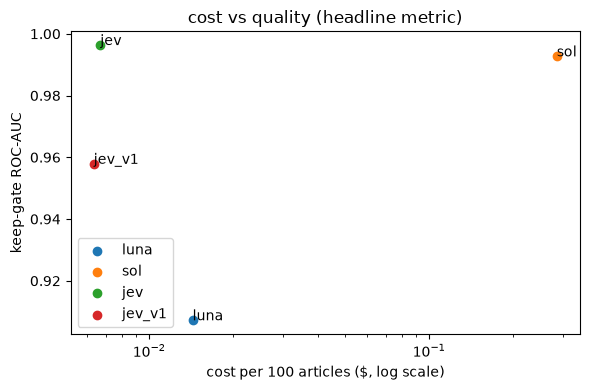

11 keep-gate disagreements vs Luna -> results/disagreements.csv


,classifier,article_id,fetched_topic,title,label_keep,luna_keep_pred,other_keep_pred
0,sol,265,Home renovation and DIY projects,Budget Breakdown: It Took $61K—and a Huge DIY ...,0,0,1
1,sol,177,Space launches and missions,"Mission Roundup: Space News from NASA, SpaceX ...",0,1,0
2,sol,233,Tabletop and board games,TGN - Tabletop Gaming News,0,1,0
3,sol,232,Tabletop and board games,New Releases - BoardGameGeek,0,1,0
4,sol,214,Video game industry news,"Game Informer - News, Reviews, Previews, Video...",0,1,0
5,jev,194,Space launches and missions,Artemis III - NASA,0,1,0
6,jev,177,Space launches and missions,"Mission Roundup: Space News from NASA, SpaceX ...",0,1,0
7,jev,233,Tabletop and board games,TGN - Tabletop Gaming News,0,1,0
8,jev,232,Tabletop and board games,New Releases - BoardGameGeek,0,1,0
9,jev,236,Tabletop and board games,Gen Con 2026 Recap: The Best New Board Games A...,0,1,0


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, s in summaries.items():
    if name == "luna_rerun":  # same cost/model as luna, not a real point of comparison here
        continue
    ax.scatter(s["cost_per_100"], s["keep_gate_roc_auc"], label=name)
    ax.annotate(name, (s["cost_per_100"], s["keep_gate_roc_auc"]))
ax.set_xscale("log")
ax.set_xlabel("cost per 100 articles ($, log scale)")
ax.set_ylabel("keep-gate ROC-AUC")
ax.set_title("cost vs quality (headline metric)")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "cost_vs_quality.png", dpi=120)
plt.show()

# Disagreement table: every row where a challenger's keep-gate prediction differs from Luna's.
disagreement_rows = []
for name in CLASSIFIERS:
    if name in ("luna", "luna_rerun"):
        continue
    luna_pred = keep_pred(scored_dfs["luna"]["relevance"], scored_dfs["luna"]["newsworthy"])
    other_pred = keep_pred(scored_dfs[name]["relevance"], scored_dfs[name]["newsworthy"])
    for i, (lp, op) in enumerate(zip(luna_pred, other_pred)):
        if lp == op:
            continue
        row = df.iloc[i]
        disagreement_rows.append(
            {
                "classifier": name,
                "article_id": int(row["article_id"]),
                "fetched_topic": row["fetched_topic"],
                "title": row["title"],
                "label_keep": int(row["label_keep_bin"]),
                "luna_keep_pred": lp,
                "other_keep_pred": op,
            }
        )
disagreement_df = pd.DataFrame(disagreement_rows)
disagreement_df.to_csv(RESULTS_DIR / "disagreements.csv", index=False)
print(f"{len(disagreement_df)} keep-gate disagreements vs Luna -> results/disagreements.csv")
disagreement_df

## Write results for the dashboard (phase 07) and `solution.md`

In [13]:
today = datetime.now(UTC).date().isoformat()

jev_block = None
if "jev" in summaries:
    jev_block = {
        "conditions": [
            {
                "name": c.name,
                "value": c.value,
                "threshold": c.threshold,
                "passed": c.passed,
                "detail": c.detail,
            }
            for c in jev_conditions
        ],
        "quality_pass": jev_quality_pass,
        "availability": availability,
        "rerun_disagreement": rerun_disagreement,
        "keep_gate_discordant_net": discordant_net,
        "bootstrap_keep_gate_auc_gap": {
            "point": jev_bootstrap_point,
            "ci95_lo": jev_bootstrap_lo,
            "ci95_hi": jev_bootstrap_hi,
        },
    }

results_payload = {
    "date": today,
    "eval_now": EVAL_NOW.isoformat(),
    "classifiers": summaries,
    "selection_agreement": agreement,
    "oracle_selection_precision": _oracle_prec,
    "jev_non_inferiority": jev_block,
    "default_classifier": default_classifier,
    "default_reason": reason,
    "total_spend_usd": total_spend,
    "jev_prompt_version": JEV_PROMPT_VERSION,
    "jev_http": jev_http,
    "relevance_saturated_share": saturation,
}
(RESULTS_DIR / f"{today}.json").write_text(json.dumps(results_payload, indent=2), encoding="utf-8")

_MD_COLUMNS = [
    "classifier",
    "n",
    "keep P",
    "keep R",
    "keep ROC-AUC",
    "rel. acc",
    "rel. ROC-AUC",
    "news ROC-AUC",
    "sel. prec.",
    "p50 ms",
    "p95 ms",
    "$/100",
]


def md_row(s: dict) -> str:
    values = [
        s["classifier"],
        s["n"],
        f"{s['keep_gate_precision']:.2f}",
        f"{s['keep_gate_recall']:.2f}",
        f"{s['keep_gate_roc_auc']:.2f}",
        f"{s['relevance_accuracy']:.2f}",
        f"{s['relevance_roc_auc']:.2f}",
        f"{s['newsworthy_roc_auc']:.2f}",
        f"{s['selection_precision']:.2f}",
        s["latency_p50_ms"],
        s["latency_p95_ms"],
        f"${s['cost_per_100']:.3f}",
    ]
    return "| " + " | ".join(str(v) for v in values) + " |"


md_lines = [
    "# Classifier eval results",
    "",
    f"Default classifier: **{default_classifier}** -- {reason}",
    "",
    f"Oracle selection precision (best possible on this label set): {_oracle_prec:.2f}",
    "",
    "| " + " | ".join(_MD_COLUMNS) + " |",
    "|" + "---|" * len(_MD_COLUMNS),
    *[md_row(s) for s in summaries.values()],
    "",
    "Selection agreement (Jaccard vs Luna, target_minutes=10 -> 8 stories): "
    + ", ".join(f"{name}={value:.2f}" for name, value in agreement.items()),
    "",
    f"`jev` = {JEV_PROMPT_VERSION} (graded score questions, D-45), the decision candidate. "
    "`jev_v1` = the phase-04 choice/boolean questions (D-43), frozen scores shown for "
    "comparison only.",
    "",
    "Relevance scores exactly 0 or 1: "
    + ", ".join(f"{name}={share:.0%}" for name, share in saturation.items()),
    "",
    f"Jev HTTP responses this run: {jev_http['responses']} "
    f"(429: {jev_http['rate_limited_429']}, 5xx: {jev_http['server_errors_5xx']})",
]
if jev_block is not None:
    md_lines += [
        "",
        "## Jev non-inferiority conditions",
        f"Quality (conditions 1-4): {'pass' if jev_block['quality_pass'] else 'fail'}. "
        f"Availability: {jev_block['availability']['failed']}/"
        f"{jev_block['availability']['responses']} responses were 429/5xx over "
        f"{jev_block['availability']['runs']} runs.",
        "",
        f"Luna-vs-Luna rerun keep-gate disagreement (noise floor): {rerun_disagreement}/{len(df)}",
        "",
        "| condition | value | threshold | pass |",
        "|---|---|---|---|",
        *[
            f"| {c['name']} | {c['value']:.3g} | {c['threshold']:.3g} | "
            f"{'yes' if c['passed'] else 'no'} |"
            for c in jev_block["conditions"]
        ],
        "",
        "Bootstrap 95% CI on keep-gate AUC gap (informational, not gating): "
        f"{jev_block['bootstrap_keep_gate_auc_gap']['point']:+.3f} "
        f"[{jev_block['bootstrap_keep_gate_auc_gap']['ci95_lo']:+.3f}, "
        f"{jev_block['bootstrap_keep_gate_auc_gap']['ci95_hi']:+.3f}]",
    ]
(RESULTS_DIR / "latest.md").write_text("\n".join(md_lines), encoding="utf-8")
print(f"wrote {RESULTS_DIR / (today + '.json')} and {RESULTS_DIR / 'latest.md'}")
print(f"total spend this run: ${total_spend:.4f}")

wrote results\2026-09-26.json and results\latest.md
total spend this run: $0.1928
